In [1]:
import pandas as pd

data = {
    'Weather': ['Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Sunny'],
    'Outcome': ['Go Out', 'Go Out', 'Go Out', 'Stay In',
                'Stay In', 'Go Out', 'Stay In', 'Go Out']
}

df = pd.DataFrame(data)

print(df)

  Weather  Outcome
0   Sunny   Go Out
1   Sunny   Go Out
2   Sunny   Go Out
3   Rainy  Stay In
4   Rainy  Stay In
5   Sunny   Go Out
6   Rainy  Stay In
7   Sunny   Go Out


In [2]:
from sklearn.preprocessing import LabelEncoder

weather_encoder = LabelEncoder()
outcome_encoder = LabelEncoder()

df['Weather'] = weather_encoder.fit_transform(df['Weather'])
df['Outcome'] = outcome_encoder.fit_transform(df['Outcome'])

print(df)

   Weather  Outcome
0        1        0
1        1        0
2        1        0
3        0        1
4        0        1
5        1        0
6        0        1
7        1        0


In [3]:
from sklearn.tree import DecisionTreeClassifier

x = df[['Weather']]
y = df['Outcome']

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=1,
    random_state=5
)

model.fit(x, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",5
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

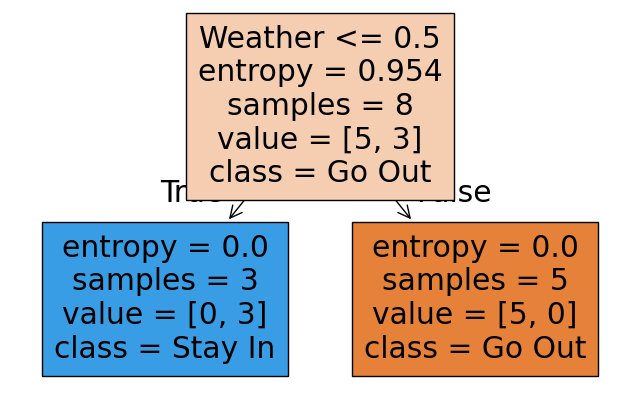

In [4]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(8, 5))

tree.plot_tree(
    model,
    feature_names=['Weather'],
    class_names=outcome_encoder.classes_,
    filled=True
)

plt.show()

In [5]:
sunny = weather_encoder.transform(['Sunny'])[0]

prediction = model.predict([[sunny]])

print("Prediction:", outcome_encoder.inverse_transform(prediction)[0])

Prediction: Go Out


c:\Users\goutham naidu bali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
